<a href="https://www.kaggle.com/code/ferhat00/copper-spot-commodities-forecasting?scriptVersionId=314433634" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/ferhat00/copper-spot-commodities-forecasting?scriptVersionId=312644377" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🟤 Copper Spot Price Forecasting — Kaggle Edition

**Kaggle-optimised build** of the `copper-forecast` repository.

### Prerequisites (Kaggle notebook settings)
| Setting | Value |
|---|---|
| **Accelerator** | GPU T4 x2 (strongly recommended) |
| **Internet** | On |
| **Persistence** | Files only |
| **Secrets** | `FRED_API_KEY`, `NASDAQ_DATA_LINK_API_KEY` (optional but recommended) |

### Speed improvements vs local run
- XGBoost / LightGBM use **CUDA GPU** when a GPU is detected
- Optuna runs **parallel trials** (`n_jobs=-1` on all CPU cores)
- Walk-forward CV uses **`joblib` parallelism**
- Downloaded data is **cached to disk**; re-runs skip the network round-trip
- Reduced `cv_step_size` window to keep memory within 16 GB

## 0. Environment Setup

In [1]:
# ── Clone the repo (skip if already present) ──────────────────────────────
import os, subprocess, sys

REPO_URL  = 'https://github.com/ferhat00/copper-forecast.git'
REPO_DIR  = '/kaggle/working/copper-forecast'
# Branch to check out.  Override via the REPO_BRANCH env var (Kaggle Secrets or
# `os.environ['REPO_BRANCH'] = '<branch>'` in a cell above) to test a feature
# branch without editing this notebook.
BRANCH    = os.environ.get('REPO_BRANCH', 'main')


def _git(*args, cwd=None):
    """Run a git command; raise RuntimeError with stderr on non-zero exit."""
    out = subprocess.run(['git', *args], cwd=cwd, capture_output=True, text=True)
    if out.returncode != 0:
        raise RuntimeError(f"git {' '.join(args)} failed:\n{out.stderr}")
    return out.stdout


if not os.path.isdir(REPO_DIR):
    _git('clone', '--depth', '1', '--branch', BRANCH, REPO_URL, REPO_DIR)
    print(f'Cloned {BRANCH} OK')
else:
    # Re-running the cell: fetch the requested branch and reset the local
    # branch to match remote.  This makes switching BRANCH idempotent.
    print(f'Repo already present — fetching {BRANCH}…')
    _git('fetch', '--depth', '1', 'origin', BRANCH, cwd=REPO_DIR)
    _git('checkout', '-B', BRANCH, f'origin/{BRANCH}', cwd=REPO_DIR)
    print(f'On branch {BRANCH}, synced to origin/{BRANCH}.')

# Echo the exact commit so the logs are unambiguous about which code ran.
sha = _git('rev-parse', '--short', 'HEAD', cwd=REPO_DIR).strip()
print(f'HEAD: {BRANCH} @ {sha}')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
print(f'Working directory: {os.getcwd()}')


Cloned main OK
HEAD: main @ 026d8d8
Working directory: /kaggle/working/copper-forecast


In [2]:
# ── Install / upgrade required packages ───────────────────────────────────
# Most scientific packages are pre-installed on Kaggle;
# only the domain-specific ones need installation.
import subprocess, sys

_PKGS = [
    'yfinance>=0.2.36',
    'fredapi>=0.5.1',
    'prophet>=1.1.5',
    'hmmlearn>=0.3.0',
    'nasdaq-data-link>=1.0.4',
    'optuna>=3.4.0',
    'shap>=0.43.0',
    'kaleido==0.2.1',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + _PKGS,
    check=True
)
print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 79.5 MB/s eta 0:00:00
All packages installed.


In [3]:
!pip install plotly

In [4]:
!pip install statsmodels

In [5]:
# ── Detect GPU and configure accelerator flags ────────────────────────────
import subprocess

def _has_gpu() -> bool:
    try:
        out = subprocess.run(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=5
        )
        return out.returncode == 0 and out.stdout.strip() != ''
    except FileNotFoundError:
        return False

GPU_AVAILABLE = _has_gpu()

# XGBoost: 'hist' on CPU, 'gpu_hist' → deprecated in XGB 2.x; use device='cuda'
XGB_DEVICE   = 'cuda' if GPU_AVAILABLE else 'cpu'
XGB_METHOD   = 'hist'               # 'hist' works on both CPU and CUDA in XGB 2.x

# LightGBM: 'gpu' device when available
LGB_DEVICE   = 'gpu' if GPU_AVAILABLE else 'cpu'

# Joblib concurrency
import os
N_JOBS = int(os.cpu_count() or 2)

print(f'GPU available : {GPU_AVAILABLE}')
print(f'XGBoost device: {XGB_DEVICE} | tree_method: {XGB_METHOD}')
print(f'LightGBM device: {LGB_DEVICE}')
print(f'Parallel jobs : {N_JOBS}')

GPU available : False
XGBoost device: cpu | tree_method: hist
LightGBM device: cpu
Parallel jobs : 4


## 1. Setup & Configuration

In [6]:
import warnings
import logging
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel, QuantileForecaster
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine, SCENARIO_TEMPLATES
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')

✅ Prophet available
✅ All imports OK


In [7]:
# ── Load API keys from Kaggle Secrets ───────────────────────────────────────
import os, shutil

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    for _key in ('EIA_API_KEY', 'FRED_API_KEY', 'ALPHA_VANTAGE_API_KEY'):
        try:
            os.environ[_key] = _secrets.get_secret(_key)
            print(f'  Secret loaded: {_key}')
        except Exception:
            print(f'  WARNING: Secret not found: {_key}')
    print('API keys loaded.')
except ImportError:
    print('Not running on Kaggle — skipping secrets loader.')

# ── Copy config.yaml from private Kaggle dataset ─────────────────────────────
REPO = '/kaggle/working/copper-forecast'
CONFIG_DATASET_PATH = '/kaggle/input/datasets/ferhat00/copper-config3/config.yaml'
CONFIG_DEST         = f'{REPO}/config.yaml'

if os.path.exists(CONFIG_DATASET_PATH):
    shutil.copy(CONFIG_DATASET_PATH, CONFIG_DEST)
    print(f'config.yaml copied → {CONFIG_DEST}')
else:
    print('WARNING: config.yaml dataset not attached — using repo default.')
    print('Attach your private dataset via: Notebook → Add Data')

# ── Configuration ─────────────────────────────────────────────────────────────
CFG = {
    'start_date':          '2010-01-01',
    'forecast_horizon':    1,              # 1-month ahead (trading days)
    'all_horizons':        [1, 5, 22, 66],
    'lags':                [1, 5, 22],
    'initial_train_size':  504,             # ~2 years
    'cv_step_size':        22,
    'holdout_size':        252,             # ~1 year OOS backtest
    'ci_alpha':            0.80,
    # ── Kaggle speed-ups (GPU for XGB/LGB) ──────────────────────────────
    'optuna_trials':       50,
    'xgb_device':         XGB_DEVICE,
    'xgb_tree_method':    XGB_METHOD,
    'lgb_device':         LGB_DEVICE,
    # ── API keys ────────────────────────────────────────────────────────
    'fred_api_key':            os.environ.get('FRED_API_KEY', None),
    'eia_api_key':             os.environ.get('EIA_API_KEY', None),
    'alpha_vantage_api_key':   os.environ.get('ALPHA_VANTAGE_API_KEY', None),
    'random_seed':         42,
    'output_dir':          '/kaggle/working/outputs',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration set:')
for k, v in CFG.items():
    if 'key' not in k or v is None:
        print(f'  {k}: {v}')
    else:
        print(f'  {k}: ***')


API keys loaded.
config.yaml copied → /kaggle/working/copper-forecast/config.yaml
Configuration set:
  start_date: 2010-01-01
  forecast_horizon: 1
  all_horizons: [1, 5, 22, 66]
  lags: [1, 5, 22]
  initial_train_size: 504
  cv_step_size: 22
  holdout_size: 252
  ci_alpha: 0.8
  optuna_trials: 50
  xgb_device: cpu
  xgb_tree_method: hist
  lgb_device: cpu
  fred_api_key: None
  eia_api_key: None
  alpha_vantage_api_key: None
  random_seed: 42
  output_dir: /kaggle/working/outputs


## 2. Data Ingestion

- **yfinance** — Copper (HG=F), DXY, Gold, Aluminium, Oil, CNY/USD, S&P 500, Shanghai
- **FRED API** — Industrial production, real yields, inflation breakeven, M2
- **CFTC COT** — Commercial/non-commercial positioning, open interest, speculative ratio

Downloaded data is cached to `/kaggle/working/data_cache.pkl` so restarted sessions skip the network round-trip.

In [8]:
import pickle, hashlib, time

# Cache key — change if you want to force a refresh
_cache_key  = hashlib.md5(
    (CFG['start_date'] + str(CFG['fred_api_key']) + str(CFG['eia_api_key']) + str(CFG['alpha_vantage_api_key'])).encode()
).hexdigest()[:8]
_cache_path = f"/kaggle/working/data_cache_{_cache_key}.pkl"

if os.path.exists(_cache_path):
    print(f'Loading cached data from {_cache_path}…')
    with open(_cache_path, 'rb') as _f:
        df_raw = pickle.load(_f)
    print('  Cache hit.')
else:
    print('Downloading data (first run — will be cached afterwards)…')
    _t0 = time.time()
    df_raw = load_data(
        start=CFG['start_date'],
        fred_api_key=CFG['fred_api_key'],
        eia_api_key=CFG['eia_api_key'],
        alpha_vantage_api_key=CFG['alpha_vantage_api_key'],
        include_cot=True,
    )
    with open(_cache_path, 'wb') as _f:
        pickle.dump(df_raw, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f'  Downloaded in {time.time()-_t0:.1f}s — cached to {_cache_path}')

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.tail()

INFO | Failed to create TzCache, reason: Error creating TzCache folder: '/root/.cache/py-yfinance' reason: [Errno 17] File exists: '/root/.cache/py-yfinance'. TzCache will not be used. Tip: You can direct cache to use a different location with 'set_tz_cache_location(mylocation)'


ERROR | $ARCH: possibly delisted; no timezone found
ERROR | $NILSY: possibly delisted; no timezone found
ERROR | $GOGL: possibly delisted; no timezone found
ERROR | $X: possibly delisted; no timezone found
ERROR | 
4 Failed downloads:
ERROR | ['ARCH', 'NILSY', 'GOGL', 'X']: possibly delisted; no timezone found
INFO | yfinance: downloaded 4254 rows for 105 tickers
WARNING | No FRED API key supplied or fredapi unavailable. Generating synthetic placeholder series.
WARNING | COT: No API key or fetch failed. Generating synthetic COT data.
INFO | COT data integrated: 4 columns added
INFO | Combined dataset: 4253 rows × 150 columns


  Downloaded in 10.9s — cached to /kaggle/working/data_cache_5687af8c.pkl
Dataset shape: (4253, 150)
Date range: 2010-01-04 → 2026-04-24
Columns: ['shanghai', 'alcoa', 'agnico', 'aluminium', 'coal_amr', 'antofagasta', 'coal_arch', 'aud_usd', 'dry_bulk_etf', 'bhp', 'coal_btu', 'oil_brent', 'caterpillar', 'oil_wti', 'cleveland_cliffs', 'copper_miners_etf', 'copper_etf', 'base_metals_etf', 'commodity_idx', 'diana_shipping', 'dxy', 'em_etf', 'eagle_bulk', 'ero_copper', 'eur_usd', 'fcx', 'first_quantum', 'franco_nevada', 'china_etf', 'gbp_usd', 'gold', 'gold_miners_etf', 'glencore', 'genco', 'golden_ocean', 'gsci_etf', 'copper_price', 'heating_oil', 'clean_energy_etf', 'latam_etf', 'ivanhoe', 'kinross', 'lumber', 'lithium_etf', 'lundin', 'matson', 'arcelormittal', 'newmont', 'nat_gas', 'anglo_american', 'norilsk', 'nucor', 'nzd_usd', 'palladium', 'commodity_broad2', 'global_miners_etf', 'construction_etf', 'platinum', 'rare_earth', 'rio', 'safe_bulkers', 'star_bulk', 'scco', 'silver', 'silv

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,commercial_net,noncommercial_net,open_interest,spec_ratio
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-20,4082.126953,66.529999,216.389999,3546.00,195.029999,51.580002,NaN,0.713500,11.304,79.589996,...,151.826493,126.697468,41.791392,147.309451,136.266137,140.443948,6099.156270,1535.049546,147274.981727,0.353141
2026-04-21,4085.076904,67.150002,203.089996,3555.25,206.770004,50.500000,NaN,0.717420,11.350,77.690002,...,152.904197,126.862486,41.745846,148.171979,135.663097,140.471930,6099.156270,1535.049546,147274.981727,0.353141
2026-04-22,4106.257812,68.529999,204.070007,3599.00,208.630005,50.990002,NaN,0.715620,11.400,80.559998,...,153.726697,126.805070,41.236317,149.356480,136.517133,140.639629,6099.156270,1535.049546,147274.981727,0.353141
2026-04-23,4093.250000,65.370003,198.960007,3616.75,198.910004,52.250000,NaN,0.715800,11.340,79.839996,...,152.748605,126.069428,42.498971,150.914305,136.576157,139.299039,6099.156270,1535.049546,147274.981727,0.353141
2026-04-24,4079.899902,66.010002,200.229996,3607.75,187.229996,50.599998,NaN,0.712962,10.900,79.820000,...,151.950421,125.174111,42.668050,150.782238,137.214797,140.047261,6210.731981,651.335950,144558.912776,0.353169


In [9]:
df_raw.describe().round(2)

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,consumer_sentiment,inventory_sales,wti_spot,nat_gas_spot,copper_lme_monthly,china_mfg_prod,commercial_net,noncommercial_net,open_interest,spec_ratio
count,4246.00,4253.00,4253.00,3098.00,1358.00,4252.00,0.0,4253.00,2110.00,4253.00,...,4244.00,4209.00,4253.00,4253.00,4224.00,4209.00,4253.00,4253.00,4253.00,4253.00
mean,2997.74,30.97,50.67,2224.84,162.89,14.21,NaN,0.79,13.33,34.26,...,105.79,67.53,57.86,116.84,119.41,123.47,11464.75,4589.64,160156.59,0.23
std,523.12,12.55,33.86,408.70,90.72,8.10,NaN,0.13,7.25,13.54,...,45.28,34.23,22.10,27.12,22.53,17.78,5313.37,4100.29,17980.20,0.14
min,1950.01,5.23,17.45,1452.00,10.87,4.09,NaN,0.57,3.91,9.45,...,29.12,1.28,16.98,64.25,76.35,80.26,-3951.07,-5312.01,127406.66,-0.02
25%,2672.75,21.48,32.90,1922.69,116.38,9.09,NaN,0.69,7.74,25.29,...,62.41,31.43,42.70,95.18,101.49,109.18,8437.68,1445.58,146080.17,0.11
50%,3050.56,29.37,43.72,2239.50,156.91,11.55,NaN,0.75,10.69,30.20,...,104.68,74.88,53.70,115.36,116.65,125.06,12218.42,4738.56,158540.43,0.24
75%,3310.18,36.97,53.17,2432.62,210.85,17.35,NaN,0.90,18.69,46.82,...,147.22,97.54,74.06,137.13,134.17,135.14,15469.77,8168.46,174073.94,0.36
max,5166.35,90.95,252.19,3873.00,442.21,61.72,NaN,1.10,41.51,81.41,...,178.48,127.99,121.63,179.80,185.70,165.49,21972.03,12874.65,203568.34,0.47


In [10]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit:')
print(audit[audit['missing_count'] > 0].to_string()
      if (audit['missing_count'] > 0).any() else 'No missing data')

Missing data audit:
                     missing_count  missing_pct
shanghai                         7          0.2
aluminium                     1155         27.2
coal_amr                      2895         68.1
antofagasta                      1          0.0
coal_arch                     4253        100.0
dry_bulk_etf                  2143         50.4
coal_btu                      1890         44.4
copper_miners_etf               76          1.8
copper_etf                     486         11.4
eagle_bulk                    3986         93.7
ero_copper                    2034         47.8
glencore                       545         12.8
genco                         1181         27.8
golden_ocean                  4253        100.0
ivanhoe                        727         17.1
lumber                         762         17.9
lithium_etf                    144          3.4
anglo_american                1333         31.3
norilsk                       4253        100.0
palladium           

## 3. Exploratory Data Analysis

In [11]:
fig_price = plot_price_history(df_raw)
fig_price.show()

In [12]:
import plotly.express as px

corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index, orientation='h',
    title='Pearson Correlation with Copper Price',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white', color=corr_all.values,
    color_continuous_scale='RdBu', color_continuous_midpoint=0,
)
fig_corr_bar.show()

In [13]:
import plotly.graph_objects as go

log_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=log_ret, nbinsx=80, name='Daily log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Daily Copper Log Returns',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {log_ret.skew():.3f}  |  Kurtosis: {log_ret.kurt():.3f}')
print(f'Ann. volatility: {log_ret.std() * np.sqrt(252):.1%}')

Skewness: -1.115  |  Kurtosis: 21.528
Ann. volatility: 23.7%


## 4. Cointegration Analysis & Regime Detection

In [14]:
df_aug, coint_results = add_cointegration_features(df_raw)

coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')

INFO | Cointegration test: t=-2.824  p=0.1581  beta=1.9533  cointegrated=False
INFO | Cointegration test: t=-3.215  p=0.0674  beta=4.1765  cointegrated=False
INFO | Cointegration: column 'oil' not in DataFrame, skipping
INFO | Cointegration test: t=-0.965  p=0.9093  beta=7.6619  cointegrated=False
INFO | Cointegration: column 'cny_usd' not in DataFrame, skipping


── Cointegration Test Results (Engle-Granger) ──
              column is_cointegrated   p_value      beta
gold            gold           False  0.158128  1.953347
aluminium  aluminium           False  0.067438  4.176544
dxy              dxy           False  0.909348  7.661942

Cointegrated pairs: []
ECT columns added: []


In [15]:
feats_prelim = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

n_holdout = CFG['holdout_size']
regime_detector = RegimeDetector(n_regimes=3)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None

INFO | RegimeDetector: fitted 3 regimes on 3802 observations (3 features)


Regime distribution:
0.0    1586
1.0    1524
2.0     944
Name: count, dtype: int64


## 5. Feature Engineering

In [16]:
feats = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(3):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Total features (incl. lags): {len(feat_cols)}')

X, y_ret, y_price = split_features_targets(feats, horizon=CFG['forecast_horizon'])
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')

Feature matrix shape: (4253, 141)
Total features (incl. lags): 132
X: (3053, 132)  |  y: (3053,)
Date range: 2014-06-05 → 2026-04-23


In [17]:
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()

## 6. Model Training & Hyper-parameter Tuning

Optuna parallelises `n_jobs` trials simultaneously.  
XGBoost and LightGBM use the GPU when one is available.

In [18]:
# ── GPU/CPU flags injected into the params dict ───────────────────────────
# XGBoostModel / LGBMModel accept a single `params` dict, not **kwargs.
from src.models import XGBoostModel, LGBMModel  # re-import to access DEFAULT_PARAMS

_xgb_params = {**XGBoostModel.DEFAULT_PARAMS, 'device': CFG['xgb_device'], 'tree_method': CFG['xgb_tree_method']}
_lgb_params = {**LGBMModel.DEFAULT_PARAMS,    'device': CFG['lgb_device']}

# Convenience factories so every instantiation picks up GPU settings
def make_xgb(): return XGBoostModel(params=_xgb_params.copy())
def make_lgb(): return LGBMModel(params=_lgb_params.copy())

naive   = NaiveModel()
linear  = LinearModel()
xgb_mdl = make_xgb()
lgb_mdl = make_lgb()

if HAS_PROPHET:
    prophet_mdl = ProphetModel()

# Holdout split
X_dev,  y_dev   = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold  = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold      = y_price.iloc[-n_holdout:]

print(f'Development set : {len(X_dev)} rows')
print(f'Holdout set     : {len(X_hold)} rows')
print(f'XGB params (GPU check): device={_xgb_params.get("device")}, tree_method={_xgb_params.get("tree_method")}')
print(f'LGB params (GPU check): device={_lgb_params.get("device")}')


Development set : 2801 rows
Holdout set     : 252 rows
XGB params (GPU check): device=cpu, tree_method=hist
LGB params (GPU check): device=cpu


In [19]:
import time

if CFG['optuna_trials'] > 0:
    print(f'Tuning XGBoost  ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print(f'Tuning LightGBM ({CFG["optuna_trials"]} trials)…')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0).')


Tuning XGBoost  (50 trials)…


INFO | XGBoost best CV RMSE: 0.013830 | params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 497.1s | best params: {'n_estimators': 253, 'learning_rate': 0.0028246357083904893, 'max_depth': 3, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_alpha': 1.3921548533046495, 'reg_lambda': 0.0060780830996819525, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM (50 trials)…


INFO | LGBM best CV RMSE: 0.013830 | params: {'n_estimators': 635, 'learning_rate': 0.035819395205338375, 'num_leaves': 26, 'max_depth': 4, 'subsample': 0.9760681097724825, 'colsample_bytree': 0.5483651026748805, 'reg_alpha': 1.0338657936132634, 'reg_lambda': 3.665446796034683, 'min_child_samples': 7, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 138.0s | best params: {'n_estimators': 635, 'learning_rate': 0.035819395205338375, 'num_leaves': 26, 'max_depth': 4, 'subsample': 0.9760681097724825, 'colsample_bytree': 0.5483651026748805, 'reg_alpha': 1.0338657936132634, 'reg_lambda': 3.665446796034683, 'min_child_samples': 7, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [20]:
w_ensemble = EnsembleModel([xgb_mdl, lgb_mdl])

base_models = [naive, linear, xgb_mdl, lgb_mdl]
if HAS_PROPHET:
    base_models.append(prophet_mdl)
base_models.append(w_ensemble)

for m in base_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

print('\nFitting stacking ensemble…')
stack_base = [make_xgb(), make_lgb()]
if HAS_PROPHET:
    stack_base.append(ProphetModel())

stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')


Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: XGBoost
Fitted: LightGBM


INFO | Prophet: fitted with 4 regressors on 2801 observations


Fitted: Prophet
Fitted: Ensemble(XGBoost+LightGBM)

Fitting stacking ensemble…


INFO | Stacking OOF: XGBoost produced 2297 predictions
INFO | Stacking OOF: LightGBM produced 2297 predictions
INFO | Prophet: fitted with 4 regressors on 504 observations
INFO | Prophet: fitted with 4 regressors on 526 observations
INFO | Prophet: fitted with 4 regressors on 548 observations
INFO | Prophet: fitted with 4 regressors on 570 observations
INFO | Prophet: fitted with 4 regressors on 592 observations
INFO | Prophet: fitted with 4 regressors on 614 observations
INFO | Prophet: fitted with 4 regressors on 636 observations
INFO | Prophet: fitted with 4 regressors on 658 observations
INFO | Prophet: fitted with 4 regressors on 680 observations
INFO | Prophet: fitted with 4 regressors on 702 observations
INFO | Prophet: fitted with 4 regressors on 724 observations
INFO | Prophet: fitted with 4 regressors on 746 observations
INFO | Prophet: fitted with 4 regressors on 768 observations
INFO | Prophet: fitted with 4 regressors on 790 observations
INFO | Prophet: fitted with 4 regre

Fitted: Stacking(XGBoost+LightGBM+Prophet)


## 7. Feature Pruning (SHAP-based)

In [21]:
try:
    prune_model = make_xgb()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped: {len(dropped)} features')
    print('\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned  = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev; X_hold_pruned = X_hold; X_pruned_full = X
    kept_cols = X_dev.columns.tolist(); USE_PRUNED = False


INFO | Feature pruning: kept 105 / 132 features (dropped 27 below threshold 0.000023)


Features before pruning: 132
Features after pruning:  105
Dropped: 27 features

Top 15 features by importance:
                     feature  mean_abs_shap
               copper_ret_1d       0.000453
                sp500_ret_1d       0.000423
         copper_ret_1d_lag_5       0.000377
                      rsi_14       0.000358
               copper_ret_5d       0.000353
         copper_vol_5d_lag_5       0.000350
                  dxy_ret_5d       0.000328
        copper_vol_5d_lag_22       0.000316
real_yield_change_22d_lag_22       0.000314
             har_rv_forecast       0.000312
                sp500_ret_5d       0.000310
            dxy_ret_1d_lag_1       0.000285
          sp500_ret_1d_lag_1       0.000275
           gold_copper_ratio       0.000273
        copper_ret_1d_lag_22       0.000268


## 8. Walk-Forward Cross-Validation

Runs in parallel across folds (`n_jobs` workers).

In [22]:
cv_models = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    cv_models.append(ProphetModel())

print(f'Running walk-forward CV…')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['forecast_horizon'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())


INFO | Evaluating model: Naive (RW)
INFO | [Naive (RW)] RMSE=0.0139  MAE=0.0102  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | Evaluating model: Linear (Ridge)


Running walk-forward CV…


INFO | [Linear (Ridge)] RMSE=0.0263  MAE=0.0129  MAPE=266.43%  DA=50.84%  Sharpe=-0.05  Skill=-2.5516
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0142  MAE=0.0104  MAPE=143.84%  DA=51.89%  Sharpe=0.20  Skill=-0.0363
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.0142  MAE=0.0105  MAPE=145.36%  DA=51.20%  Sharpe=-0.03  Skill=-0.0435
INFO | Evaluating model: Ensemble(XGBoost+LightGBM)
INFO | [Ensemble(XGBoost+LightGBM)] RMSE=0.0142  MAE=0.0104  MAPE=142.71%  DA=51.57%  Sharpe=-0.03  Skill=-0.0367
INFO | Evaluating model: Prophet
INFO | Prophet: fitted with 4 regressors on 504 observations
INFO | Prophet: fitted with 4 regressors on 526 observations
INFO | Prophet: fitted with 4 regressors on 548 observations
INFO | Prophet: fitted with 4 regressors on 570 observations
INFO | Prophet: fitted with 4 regressors on 592 observations
INFO | Prophet: fitted with 4 regressors on 614 observations
INFO | Prophet: fitted with 4 regressors on 636 observations
INFO | Prophet:


── Walk-Forward CV Metrics ──
                                rmse       mae        mape  directional_accuracy  signal_sharpe  information_ratio  rmse_skill
model                                                                                                                         
Naive (RW)                  0.013948  0.010205  100.000000              0.000000       0.000000           0.000000    0.000000
Linear (Ridge)              0.026286  0.012928  266.433715              0.508405      -0.047974          -0.047974   -2.551645
XGBoost                     0.014199  0.010444  143.835383              0.518855       0.203328           0.203328   -0.036305
LightGBM                    0.014248  0.010490  145.362347              0.512040      -0.033292          -0.033292   -0.043453
Ensemble(XGBoost+LightGBM)  0.014202  0.010441  142.707378              0.515675      -0.034936          -0.034936   -0.036719
Prophet                     0.014330  0.010560  128.254112              0.498864

In [23]:
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()

fig_cmp_da = plot_model_comparison(
    summary, metric='directional_accuracy',
    title='Model Comparison — Directional Accuracy'
)
fig_cmp_da.show()

best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()

Best model by CV RMSE: Naive (RW)


## 9. Out-of-Sample Backtesting

In [24]:
oos_results = {}; oos_metrics = {}

oos_model_list = [
    NaiveModel(), LinearModel(),
    make_xgb(), make_lgb(),
    EnsembleModel([make_xgb(), make_lgb()]),
]
if HAS_PROPHET:
    oos_model_list.append(ProphetModel())

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['forecast_horizon'],
    )
    oos_results[m.name] = oos_df; oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics ──')
print(oos_summary.to_string())

# Selection rule: highest signal_sharpe (risk-adjusted skill of a long/short strategy
# that takes the sign of the prediction).  RMSE on log-returns is biased toward the
# zero-prediction Naive baseline at short horizons, so we don't use it as the primary
# rule.  We do display rmse_skill (= 1 - rmse_model^2 / rmse_naive^2) as a sanity check.
best_oos = oos_summary['signal_sharpe'].idxmax()
print(f"\nSelected model (max signal_sharpe): {best_oos}  "
      f"(Sharpe={oos_summary.loc[best_oos, 'signal_sharpe']:.3f}, "
      f"RMSE skill vs Naive={oos_summary.loc[best_oos, 'rmse_skill']:.4f})")
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


INFO | [Naive (RW) OOS] RMSE=0.0243  MAE=0.0138  MAPE=100.00%  DA=0.00%  Sharpe=0.00  Skill=0.0000
INFO | [Linear (Ridge) OOS] RMSE=0.0249  MAE=0.0152  MAPE=222.67%  DA=51.85%  Sharpe=1.91  Skill=-0.0529
INFO | [XGBoost OOS] RMSE=0.0244  MAE=0.0142  MAPE=136.24%  DA=53.09%  Sharpe=0.73  Skill=-0.0085
INFO | [LightGBM OOS] RMSE=0.0244  MAE=0.0143  MAPE=158.81%  DA=54.32%  Sharpe=1.89  Skill=-0.0103
INFO | [Ensemble(XGBoost+LightGBM) OOS] RMSE=0.0243  MAE=0.0142  MAPE=146.26%  DA=55.14%  Sharpe=1.66  Skill=-0.0065
INFO | Prophet: fitted with 4 regressors on 2801 observations
INFO | Prophet: fitted with 4 regressors on 2801 observations
INFO | [Prophet OOS] RMSE=0.0244  MAE=0.0141  MAPE=158.60%  DA=52.67%  Sharpe=0.63  Skill=-0.0079


── Out-of-Sample Backtest Metrics ──
                                rmse       mae        mape  directional_accuracy  signal_sharpe  information_ratio  rmse_skill
Naive (RW)                  0.024262  0.013790  100.000000              0.000000       0.000000           0.000000    0.000000
Linear (Ridge)              0.024895  0.015215  222.665008              0.518519       1.910990           1.910990   -0.052909
XGBoost                     0.024364  0.014237  136.238743              0.530864       0.726228           0.726228   -0.008462
LightGBM                    0.024386  0.014329  158.808891              0.543210       1.890744           1.890744   -0.010261
Ensemble(XGBoost+LightGBM)  0.024340  0.014244  146.257697              0.551440       1.655015           1.655015   -0.006470
Prophet                     0.024357  0.014082  158.600450              0.526749       0.625416           0.625416   -0.007901

Selected model (max signal_sharpe): Linear (Ridge)  (Sharpe=1.911, RMSE s

## 10. Forecast with 80% Confidence Interval

In [25]:
q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
q_model.fit(X_dev_pruned, y_dev)
q_preds_ret = q_model.predict(X_hold_pruned)

last_price = df_aug['copper_price'].iloc[-(n_holdout + 1)]
forecast_df = pd.DataFrame({
    'date':   X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
}).set_index('date')


fig_fc = plot_forecast_with_ci(df_raw['copper_price'], forecast_df.reset_index())
fig_fc.show()

actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= forecast_df['lower']) & (actual_hold <= forecast_df['upper'])).mean()
print(f'80% CI actual coverage: {inside:.1%}  (target: 80%)')

80% CI actual coverage: 4.8%  (target: 80%)


## 11. SHAP Explainability

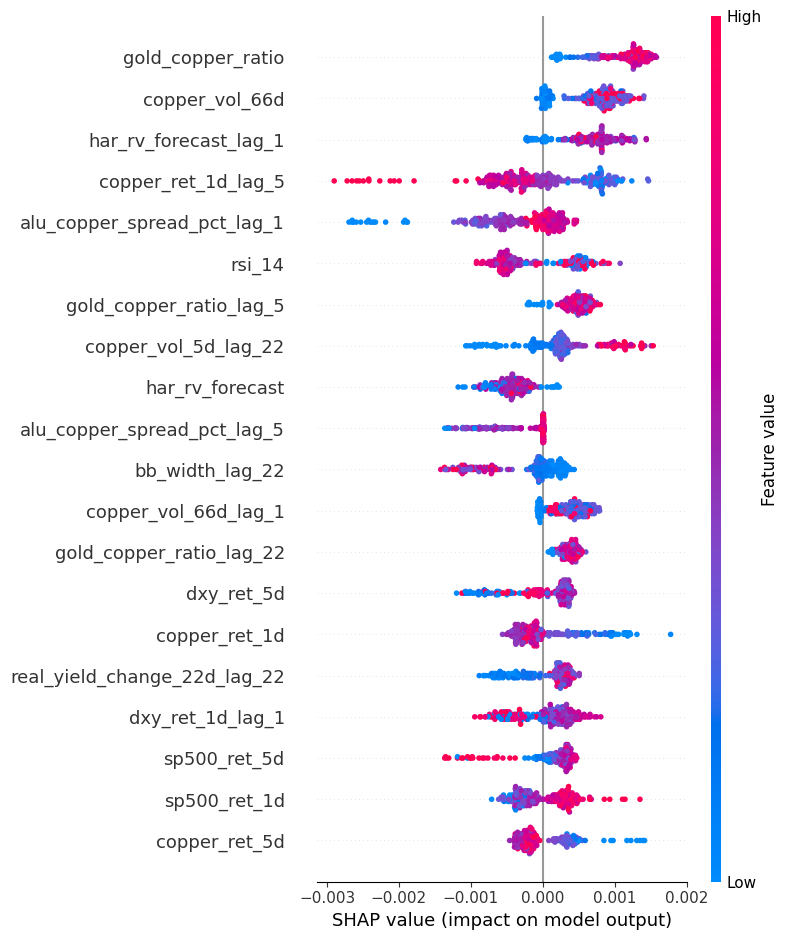

SHAP beeswarm saved to /kaggle/working/outputs/shap_beeswarm.png
Top 10 features by mean |SHAP|:
gold_copper_ratio              0.001126
copper_vol_66d                 0.000694
har_rv_forecast_lag_1          0.000655
copper_ret_1d_lag_5            0.000602
alu_copper_spread_pct_lag_1    0.000505
rsi_14                         0.000495
gold_copper_ratio_lag_5        0.000476
copper_vol_5d_lag_22           0.000447
har_rv_forecast                0.000438
alu_copper_spread_pct_lag_5    0.000404


In [26]:
try:
    import shap, matplotlib.pyplot as plt
    shap.initjs()

    xgb_shap = make_xgb()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
    plt.tight_layout()
    _bp = os.path.join(CFG['output_dir'], 'shap_beeswarm.png')
    plt.savefig(_bp, dpi=150, bbox_inches='tight'); plt.show()
    print(f'SHAP beeswarm saved to {_bp}')

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except Exception as e:
    print(f'SHAP skipped: {e}')


## 12. Interactive Plotly Visualisations

In [27]:
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

# Rolling signal Sharpe of the SELECTED model (max signal_sharpe — same rule as the
# OOS cell above; this is the model that goes into forecast_summary.json).
best_oos_name = oos_summary['signal_sharpe'].idxmax()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']
rolling_sharpe = (
    signal_ret_oos.rolling(60).mean() /
    signal_ret_oos.rolling(60).std().replace(0, np.nan)
) * np.sqrt(252 / CFG['forecast_horizon'])

fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (60-day)', line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 60-Day Signal Sharpe — {best_oos_name}',
    template='plotly_white', yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()


## 13. Scenario Analysis

In [28]:
latest_features = X_pruned_full.tail(1)
current_copper  = float(df_aug['copper_price'].iloc[-1])

scenario_model = EnsembleModel([make_xgb(), make_lgb()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['forecast_horizon'],
)
print(f'Current copper price    : ${current_copper:,.0f}/t')
print(f'Baseline {CFG["forecast_horizon"]}-day forecast: ${engine.base_price:,.0f}/t')

scenario_report = engine.report()
print('\n── Scenario Report ──')
print(scenario_report.to_string())

fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()

# DXY sensitivity sweep
dxy_shocks = np.linspace(-0.10, 0.10, 21)
sweep_dxy  = engine.sweep('dxy_ret_22d', dxy_shocks.tolist(), label='DXY 22d return shock')
fig_sweep  = go.Figure(go.Scatter(
    x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
    mode='lines+markers', line=dict(color='#b87333'), name='Forecast price',
))
fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                    annotation_text='Baseline')
fig_sweep.update_layout(
    title='Copper Price Sensitivity to DXY Return Shock',
    xaxis_title='DXY 22d return shock (additive)',
    yaxis_title='Forecast Copper Price ($/t)',
    template='plotly_white',
)
fig_sweep.show()

# Custom geopolitical / tariff shock
result = engine.run('geo_tariff_shock', shocks={
    'dxy_ret_22d': 0.04, 'sp500_ret_22d': -0.08,
    'copper_vol_22d': 0.05, 'real_yield_change_22d': 0.3,
})
print('\nCustom scenario result:')
for k, v in result.items():
    print(f'  {k}: {v}')


INFO | Scenario 'bull_strong': base=13317  forecast=13315  delta=-1 (-0.0%)
INFO | Scenario 'bear_strong': base=13317  forecast=13313  delta=-3 (-0.0%)
WARNING | Shock target 'cny_usd_level' not in feature set — skipped.
INFO | Scenario 'china_demand_surge': base=13317  forecast=13317  delta=+0 (0.0%)
INFO | Scenario 'supply_disruption': base=13317  forecast=13314  delta=-2 (-0.0%)
INFO | Scenario 'comex_inventory_drop_40pct': base=13317  forecast=13315  delta=-1 (-0.0%)
WARNING | Shock target 'infl_be_level' not in feature set — skipped.
INFO | Scenario 'high_inflation': base=13317  forecast=13315  delta=-1 (-0.0%)
INFO | Scenario 'us_tariff_shock': base=13317  forecast=13313  delta=-3 (-0.0%)


Current copper price    : $13,280/t
Baseline 1-day forecast: $13,317/t

── Scenario Report ──
                            base_price  scenario_price  delta  delta_pct
scenario                                                                
bear_strong                   13316.54        13313.19  -3.35      -0.03
us_tariff_shock               13316.54        13313.19  -3.35      -0.03
supply_disruption             13316.54        13314.48  -2.06      -0.02
bull_strong                   13316.54        13315.35  -1.19      -0.01
high_inflation                13316.54        13315.35  -1.19      -0.01
comex_inventory_drop_40pct    13316.54        13315.27  -1.27      -0.01
china_demand_surge            13316.54        13316.54   0.00       0.00


INFO | Scenario 'geo_tariff_shock': base=13317  forecast=13311  delta=-5 (-0.0%)



Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 13316.54
  scenario_price: 13311.06
  delta: -5.48
  delta_pct: -0.04


## 14. Export Results

In [29]:
import json
from datetime import date

out_dir = CFG['output_dir']

forecast_df.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci.csv'), index=False
)

for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

summary_json = {
    'generated_at':      date.today().isoformat(),
    'current_price':     round(current_copper, 2),
    'baseline_forecast': round(engine.base_price, 2),
    'horizon_days':      CFG['forecast_horizon'],
    'best_model':        best_oos_name,
    'oos_metrics':       oos_metrics[best_oos_name],
    'scenarios':         scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'All outputs saved to {out_dir}/')
print('Files:', os.listdir(out_dir))

All outputs saved to /kaggle/working/outputs/
Files: ['forecast_ci.csv', 'oos_LightGBM.csv', 'shap_beeswarm.png', 'cointegration_results.csv', 'oos_EnsembleXGBoost+LightGBM.csv', 'oos_Linear_Ridge.csv', 'scenario_report.csv', 'model_comparison.csv', 'oos_Naive_RW.csv', 'oos_XGBoost.csv', 'oos_Prophet.csv', 'forecast_summary.json']


---
## Summary

| Optimisation | Detail |
|---|---|
| **GPU acceleration** | XGBoost `device='cuda'`, LightGBM `device='gpu'` when T4/P100 is detected |
| **Parallel Optuna** | `n_jobs=N_JOBS` → all CPU cores used per tuning study |
| **Parallel CV folds** | `compare_models(n_jobs=N_JOBS)` → folds run concurrently via joblib |
| **Data cache** | Pickle cache keyed by date + API keys — restarted sessions load instantly |
| **Kaggle secrets** | FRED & Nasdaq API keys loaded from Kaggle Secrets, never hard-coded |
| **Shallow clone** | `git clone --depth 1` downloads only the latest commit |

Expected runtimes on Kaggle (GPU T4 x2, Internet on):

| Section | ~Time |
|---|---|
| Clone + install | 2–3 min (first run) / <10 s (cached) |
| Data download | 1–2 min (first run) / instant (cached) |
| Feature engineering | ~30 s |
| Optuna tuning (50 trials each) | ~5 min |
| Walk-forward CV (all models) | ~8–12 min |
| OOS backtest | ~3–5 min |
| SHAP + visualisations | ~2 min |
| **Total** | **~25–35 min** (vs ~60–90 min on CPU-only) |

In [30]:
# ── Email forecast results after pipeline run ────────────────────────────────
import smtplib, os
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders


def send_email_with_attachments(sender_email, sender_password, receiver_email,
                                subject, body, attachments):
    """Send an email with attachments.

    `attachments` is an iterable of either bare paths (use the on-disk basename
    as the filename the recipient sees) or (path, attached_name) tuples (use the
    given name; preserves the on-disk extension if the supplied name omits one).
    """
    msg = MIMEMultipart()
    msg['From']    = sender_email
    msg['To']      = receiver_email
    msg['Subject'] = subject
    msg.attach(MIMEText(body, 'plain'))

    for item in attachments:
        if isinstance(item, (tuple, list)):
            file_path, attached_name = item
        else:
            file_path, attached_name = item, None
        if not os.path.exists(file_path):
            print(f'  Skipping missing attachment: {file_path}')
            continue
        with open(file_path, 'rb') as f:
            part = MIMEBase('application', 'octet-stream')
            part.set_payload(f.read())
        encoders.encode_base64(part)
        # Preserve the on-disk extension if the caller didn't include one.
        if attached_name is None:
            attached_name = os.path.basename(file_path)
        elif not os.path.splitext(attached_name)[1]:
            attached_name += os.path.splitext(file_path)[1]
        part.add_header('Content-Disposition',
                        f'attachment; filename={attached_name}')
        msg.attach(part)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(sender_email, sender_password)
        server.send_message(msg)
    print(f'Email sent to {receiver_email}')


def save_figure(fig, png_path):
    """Save a Plotly figure as PNG, falling back to HTML if kaleido is unavailable."""
    try:
        fig.write_image(png_path, scale=2)
        print(f'Saved {os.path.basename(png_path)}')
        return png_path
    except Exception as e:
        print(f'Could not save {os.path.basename(png_path)}: {e}')
        html_path = png_path.replace('.png', '.html')
        fig.write_html(html_path)
        print(f'  Saved fallback {os.path.basename(html_path)}')
        return html_path


def _safe_model_name(name):
    """Filesystem-safe slug for a model name (strip spaces, brackets, etc.)."""
    return (name.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('/', '_').replace('+', 'plus'))


# ── Resolve the forecast horizon to an unambiguous human label ───────────────
# CFG['forecast_horizon'] is in *trading* days (~252 per year), which is easy to
# misread.  These labels make the period explicit in both the subject line and
# the body so the recipient never has to guess "is this 1 day or 1 month?".
_HORIZON_LABELS = {
    1:   '1 trading day (next day)',
    5:   '5 trading days (~1 week)',
    22:  '22 trading days (~1 month)',
    66:  '66 trading days (~1 quarter)',
    252: '252 trading days (~1 year)',
}
_h = CFG['forecast_horizon']
horizon_label = _HORIZON_LABELS.get(_h, f'{_h} trading days')
horizon_tag   = f'{_h}td'                       # short tag for filenames, e.g. '22td'
_day_word     = 'day' if _h == 1 else 'days'    # singular/plural for the body line

# Data-as-of and approximate target dates.
as_of_dt    = df_aug.index[-1]
target_dt   = as_of_dt + pd.offsets.BDay(_h)
as_of_str   = as_of_dt.date().isoformat()
target_str  = target_dt.date().isoformat()


# ── Save forecast figures as PNG (HTML fallback if kaleido unavailable) ───────
out_dir = CFG['output_dir']

saved_fc   = save_figure(fig_fc,  os.path.join(out_dir, 'forecast_ci.png'))
saved_cmp  = save_figure(fig_cmp, os.path.join(out_dir, 'model_comparison.png'))
# Build the folds chart from the SELECTED model (the one written to forecast_summary.json),
# not the CV-stage winner — fig_cv shows best_name (often the Naive baseline) and would
# misrepresent which model the email is reporting on.
fig_best   = plot_cv_results(oos_results[best_oos_name], model_name=f'{best_oos_name} (OOS)')
saved_best = save_figure(fig_best, os.path.join(out_dir, 'best_model_oos.png'))

# Recipient-facing attachment names embed both the model and the horizon so the
# files are self-describing in a mail client (no need to open the body).
_safe_best   = _safe_model_name(best_oos_name)
_attachments = [
    (saved_fc,
     f'forecast_ci_{horizon_tag}_QuantileForecaster.png'),
    (saved_cmp,
     f'model_comparison_oos_{horizon_tag}_all_candidates.png'),
    (saved_best,
     f'oos_folds_{_safe_best}_{horizon_tag}.png'),
    # The SHAP beeswarm comes from the SHAP cell upstream, which always uses an
    # XGBoost regressor (`make_xgb()`).  That model is NOT necessarily the one
    # selected for the forecast — it's used purely as the explainability model.
    (os.path.join(out_dir, 'shap_beeswarm.png'),
     'shap_beeswarm_XGBoost_explainability.png'),
]


# ── Load email credentials from Kaggle Secrets ───────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets        = UserSecretsClient()
    sender_email    = _secrets.get_secret('GMAIL_ADDRESS')
    sender_password = _secrets.get_secret('GMAIL_APP_PASSWORD')
except Exception as e:
    raise RuntimeError(f'Email secrets not found — add GMAIL_ADDRESS and GMAIL_APP_PASSWORD to Kaggle Secrets. ({e})')

# Pull the headline metrics for the selected model so the email body shows *why* it won.
_sel = oos_summary.loc[best_oos_name]
email_body = (
    f'Copper Forecast Pipeline complete.\n'
    f'Forecast horizon : {horizon_label}\n'
    f'Data as of       : {as_of_str}\n'
    f'Forecast for     : {target_str}  (= as-of + {_h} trading {_day_word})\n'
    f'\n'
    f'Selected model   : {best_oos_name}  (max OOS signal_sharpe — used for the forecast)\n'
    f'  signal_sharpe        : {_sel["signal_sharpe"]:+.3f}\n'
    f'  directional_accuracy : {_sel["directional_accuracy"]:.3f}\n'
    f'  rmse_skill vs Naive  : {_sel["rmse_skill"]:+.4f}  (>0 means lower RMSE than Naive)\n'
    f'  rmse                 : {_sel["rmse"]:.4f}\n'
    f'CV-stage winner  : {best_name}  (informational only, not used for the forecast)\n'
    f'\n'
    f'Current price    : ${current_copper:,.0f}/t\n'
    f'Baseline forecast: ${engine.base_price:,.0f}/t  ({horizon_label})\n'
    f'\n'
    f'Attachments (model annotated in each filename):\n'
    f'  - forecast_ci_{horizon_tag}_QuantileForecaster.png\n'
    f'      Forecast & 80% confidence interval over the {horizon_label} horizon.\n'
    f'      Built from a QuantileForecaster (LightGBM quantile regression, 10/50/90).\n'
    f'  - model_comparison_oos_{horizon_tag}_all_candidates.png\n'
    f'      OOS metric comparison across ALL candidate models for the {horizon_label} horizon.\n'
    f'  - oos_folds_{_safe_best}_{horizon_tag}.png\n'
    f'      OOS folds (predicted vs actual) for the SELECTED model: {best_oos_name}.\n'
    f'  - shap_beeswarm_XGBoost_explainability.png\n'
    f'      SHAP feature importances. Computed on an XGBoost regressor used purely for\n'
    f'      explainability — this is NOT necessarily the selected forecasting model.\n'
)

send_email_with_attachments(
    sender_email    = sender_email,
    sender_password = sender_password,
    receiver_email  = sender_email,
    subject         = f'Copper Forecast — {horizon_label} — {best_oos_name} ({as_of_str})',
    body            = email_body,
    attachments     = _attachments,
)


Saved forecast_ci.png
Saved model_comparison.png
Saved best_model_oos.png
Email sent to ferhat00@gmail.com
